In [1]:
## Modélisation Prédictive : Heart Disease Risk

In [2]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


data = pd.read_csv('healthcare_synthetic_data.csv')


data["SBMI"] = np.sqrt(data["BMI"])
data["SWeight"] = np.sqrt(data["Weight_kg"])
data["S_Fasting_Blood_Sugar"] = np.sqrt(data["Fasting_Blood_Sugar"])
data["L_Height_cm"] = np.log(data["Height_cm"])


if 'Patient_ID' in data.columns:
    data = data.drop(columns=['Patient_ID'])


cat_vars = [
    "Gender", "Smoking_Status", "Family_History", "Alcohol_Consumption", 
    "Physical_Activity_Level", "Stress_Level", "Heart_Disease_Risk", "Sleep_Hours"
]

for var in cat_vars:
    data[var] = data[var].astype('category')

gender_map = {0: "Female", 1: "Male"}
data["Gender"] = data["Gender"].map(gender_map).astype('category')

print("--- Aperçu des types et valeurs manquantes ---")
print(data.info())

print("\n--- Statistiques descriptives (Numériques) ---")
print(data.describe())

print("\n--- Statistiques descriptives (Catégorielles) ---")
print(data.describe(include=['category']))

--- Aperçu des types et valeurs manquantes ---
<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Age                      15000 non-null  int64   
 1   Gender                   15000 non-null  category
 2   Height_cm                15000 non-null  float64 
 3   Weight_kg                15000 non-null  float64 
 4   BMI                      15000 non-null  float64 
 5   Systolic_BP              15000 non-null  int64   
 6   Diastolic_BP             15000 non-null  int64   
 7   Cholesterol_Total        15000 non-null  int64   
 8   Cholesterol_LDL          15000 non-null  int64   
 9   Cholesterol_HDL          15000 non-null  int64   
 10  Fasting_Blood_Sugar      15000 non-null  int64   
 11  Smoking_Status           15000 non-null  category
 12  Alcohol_Consumption      15000 non-null  category
 13  Physical_Activity_Level  

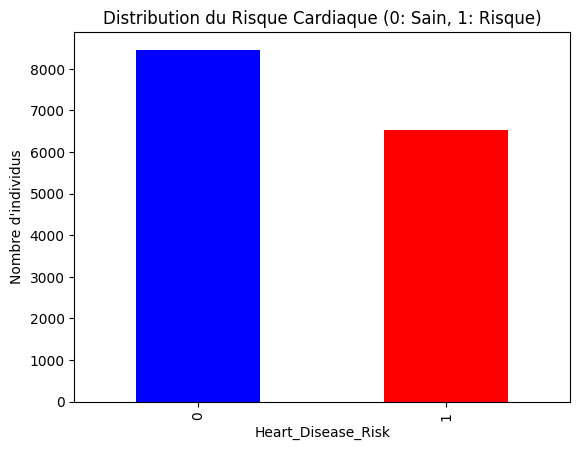

,Gender_Male,Smoking_Status_1,Family_History_1,Alcohol_Consumption_1,Alcohol_Consumption_2,Physical_Activity_Level_1,Physical_Activity_Level_2,Physical_Activity_Level_3,Stress_Level_2,Stress_Level_3,...,SBMI,SWeight,S_Fasting_Blood_Sugar,L_Height_cm,Age,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL
0,False,False,False,True,False,False,False,True,False,False,...,4.878524,7.162402,9.110434,4.989752,60,140,89,217,151,52
1,False,False,False,False,False,True,False,False,False,False,...,5.412947,8.752143,10.770330,5.086361,53,128,81,203,119,38
2,True,False,False,False,False,False,False,False,False,False,...,5.504544,9.612492,9.486833,5.163070,62,141,100,173,124,45
3,True,False,False,False,False,True,False,False,True,False,...,4.785394,8.300602,9.000000,5.155024,73,136,96,193,117,45
4,True,False,False,True,False,False,True,False,True,False,...,5.000000,8.933085,8.888194,5.185149,52,122,80,236,153,41


In [3]:

qual_cols = ["Gender", "Smoking_Status", "Family_History", "Alcohol_Consumption", 
             "Physical_Activity_Level", "Stress_Level", "Sleep_Hours"]

df_dummies = pd.get_dummies(data[qual_cols], drop_first=True)

quant_cols = ["SBMI", "SWeight", "S_Fasting_Blood_Sugar", "L_Height_cm", 
              "Age", "Systolic_BP", "Diastolic_BP", "Cholesterol_Total", 
              "Cholesterol_LDL", "Cholesterol_HDL"]

df_quant = data[quant_cols]

X = pd.concat([df_dummies, df_quant], axis=1)

y = data["Heart_Disease_Risk"].map(lambda x: 1 if x in ["Yes", 1, "1"] else 0)

y.value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title("Distribution du Risque Cardiaque (0: Sain, 1: Risque)")
plt.xlabel("Heart_Disease_Risk")
plt.ylabel("Nombre d'individus")
plt.show()

X.head()



In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)


print(f"Taille de l'échantillon d'apprentissage : {X_train.shape[0]} individus")
print(f"Taille de l'échantillon de test : {X_test.shape[0]} individus")

Taille de l'échantillon d'apprentissage : 12000 individus
Taille de l'échantillon de test : 3000 individus


Cette étape fondamentale pour évaluer la capacité de généralisation des algorithmes. En isolant une portion des données que le modèle ne verra jamais durant sa phase d'entraînement, on simule l'arrivée de nouveaux patients afin de mesurer ses performances réelles. Cette procédure est la seule manière fiable de détecter l'overfitting.

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Prévision par modèles linéaires

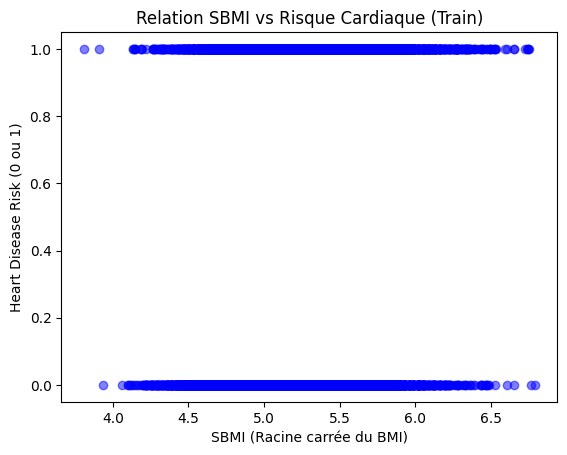

R2 (Train) = -93.72586080916959


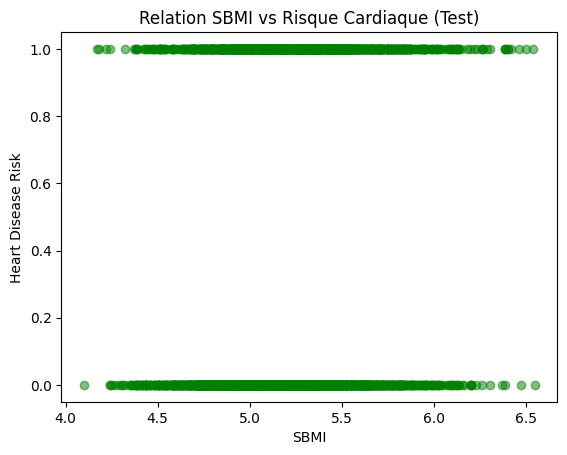

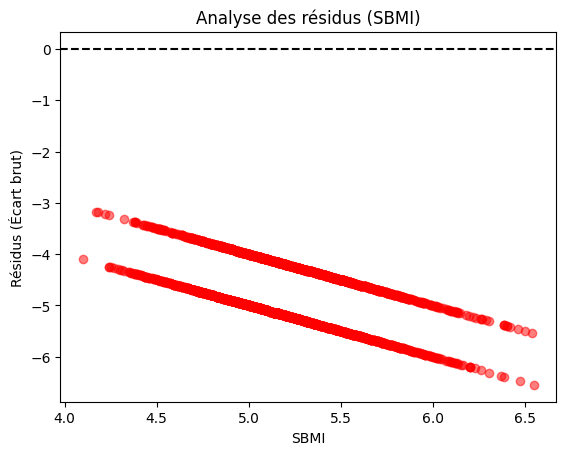

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score


y_train_num = y_train.astype(float)
y_test_num = y_test.astype(float)

# 1. Graphique Train
plt.scatter(X_train["SBMI"], y_train_num, alpha=0.5, color='blue', label='Train Data')
plt.xlabel("SBMI (Racine carrée du BMI)")
plt.ylabel("Heart Disease Risk (0 ou 1)")
plt.title("Relation SBMI vs Risque Cardiaque (Train)")
plt.show()


print("R2 (Train) =", r2_score(y_train_num, X_train["SBMI"]))

# 3. Graphique Test
plt.scatter(X_test["SBMI"], y_test_num, alpha=0.5, color='green', label='Test Data')
plt.xlabel("SBMI")
plt.ylabel("Heart Disease Risk")
plt.title("Relation SBMI vs Risque Cardiaque (Test)")
plt.show()


residus = y_test_num - X_test["SBMI"]

plt.scatter(X_test["SBMI"], residus, alpha=0.5, color='red')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel("SBMI")
plt.ylabel("Résidus (Écart brut)")
plt.title("Analyse des résidus (SBMI)")
plt.show()

Les visualisations montrent une superposition quasi totale des classes (0 et 1) sur l'ensemble de la plage de valeurs du SBMI. L'analyse des résidus révèle une erreur systématique importante, confirmée par un $R^2$ fortement négatif. Cela démontre que le risque cardiaque ne peut pas être modélisé par une fonction linéaire directe de la corpulence. Ces résultats valident la nécessité de passer à une Régression Logistique, qui transformera les variables explicatives en probabilités via une fonction sigmoïde pour mieux gérer la nature binaire de la cible.

In [10]:
from sklearn.metrics import mean_squared_error, r2_score

mse_test = mean_squared_error(y_test, X_test["SBMI"])
print(f"MSE (Test) = {mse_test:.4f}")

r2_test = r2_score(y_test, X_test["SBMI"])
print(f"R2 (Test) = {r2_test:.4f}")

MSE (Test) = 23.2025
R2 (Test) = -93.3559


Les résultats obtenus sur l'échantillon test ($MSE = 23.2$ et $R^2 = -93.4$) confirment l'échec total d'une approche par régression linéaire directe. Ces valeurs aberrantes s'expliquent par le conflit de nature entre les variables : on tente de faire correspondre une variable biométrique continue (SBMI) à une classe binaire ($0/1$). Mathématiquement, cela revient à projeter des données sur un espace qui n'est pas le leur. Cela justifie de manière empirique la nécessité d'utiliser des modèles de classification (Régression Logistique, SVM, Arbres) qui utilisent des fonctions de lien ou des frontières de décision adaptées.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

scores_comparaison = {}

param_grid_log = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear'] 
}

log_grid = GridSearchCV(LogisticRegression(), param_grid_log, cv=5, scoring='accuracy')
log_grid.fit(X_train_scaled, y_train)

scores_comparaison['Logistique_Optimisee'] = log_grid.best_score_
print(f"Meilleurs paramètres Logistique: {log_grid.best_params_}")

c:\Users\eliot\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\eliot\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\eliot\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty=

Meilleurs paramètres Logistique: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}


c:\Users\eliot\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [12]:
from sklearn.svm import SVC

param_grid_svm = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf'] 
}

svm_grid = GridSearchCV(SVC(), param_grid_svm, cv=5, scoring='accuracy')
svm_grid.fit(X_train_scaled, y_train)

scores_comparaison['SVM_RBF'] = svm_grid.best_score_

In [13]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Forêt Aléatoire (Random Forest)
rf_grid = GridSearchCV(RandomForestClassifier(), {'n_estimators': [100, 200], 'max_depth': [5, 10, None]}, cv=5)
rf_grid.fit(X_train, y_train) # Pas besoin de scaling pour les arbres
scores_comparaison['Random_Forest'] = rf_grid.best_score_

# Boosting (Gradient Boosting)
gb_grid = GridSearchCV(GradientBoostingClassifier(), {'learning_rate': [0.01, 0.1], 'n_estimators': [100]}, cv=5)
gb_grid.fit(X_train, y_train)
scores_comparaison['Boosting'] = gb_grid.best_score_

In [14]:
from sklearn.neural_network import MLPClassifier

param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100, 50)],
    'activation': ['relu'],
    'alpha': [0.0001, 0.01]
}

mlp_grid = GridSearchCV(MLPClassifier(max_iter=500), param_grid_mlp, cv=5)
mlp_grid.fit(X_train_scaled, y_train)
scores_comparaison['Reseau_Neurones'] = mlp_grid.best_score_

c:\Users\eliot\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\eliot\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\eliot\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\eliot\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the opti

In [15]:
# Affichage des résultats
for modele, score in scores_comparaison.items():
    print(f"{modele} : Accuracy par CV = {score:.4f}")

Logistique_Optimisee : Accuracy par CV = 0.7380
SVM_RBF : Accuracy par CV = 0.7304
Random_Forest : Accuracy par CV = 0.7265
Boosting : Accuracy par CV = 0.7316
Reseau_Neurones : Accuracy par CV = 0.6922


Les résultats montrent que la Régression Logistique optimisée surpasse les modèles complexes avec une précision de 73,80 %, ce qui prouve que la frontière de décision du risque cardiaque est essentiellement linéaire dans ce jeu de données. L'échec des modèles non linéaires, notamment le Réseau de Neurones (69,22 %), souligne un phénomène de sur-apprentissage ou une trop faible quantité de données pour justifier leur complexité. Dans une perspective d'ingénierie, nous privilégierons donc le modèle linéaire pour sa robustesse et sa plus grande interprétabilité des facteurs de risque.

In [16]:

best_log_model = log_grid.best_estimator_
y_pred_test = best_log_model.predict(X_test_scaled)

from sklearn.metrics import accuracy_score, confusion_matrix

final_accuracy = accuracy_score(y_test, y_pred_test)
print(f"Performance finale sur échantillon TEST : {final_accuracy:.4f}")
print("\nMatrice de confusion :")
print(confusion_matrix(y_test, y_pred_test))

Performance finale sur échantillon TEST : 0.7383

Matrice de confusion :
[[1369  323]
 [ 462  846]]


La cohérence entre les scores Train et Test (0.7383 vs 0.7380) confirme la robustesse du modèle. Le modèle a plus de mal avec les faux négatifs qu'avec les faux positifs. Le modèle est précis à 73.83% et est donc très performant. 